<div dir="rtl" style="text-align:center; font-family:'Segoe UI','B Nazanin',Arial,sans-serif; font-size:28px; font-weight:bold; margin:20px 0; color:#2e86de;">
آزمون فرض
</div>

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

In [3]:
df = pd.read_csv("Divar.csv")

C:\Users\ASUS\AppData\Local\Temp\ipykernel_4696\1381234337.py:1: DtypeWarning: Columns (0: rent_to_single, 1: floor, 2: total_floors_count, 3: extra_person_capacity) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("Divar.csv")


<div dir="rtl" style="text-align:right; font-family:Arial; font-size:20px; font-weight:bold; margin:16px 0 8px; border-right:4px solid #4a90d9; padding-right:10px;">
سوال ۱: با توجه به رشد مهاجرت افراد از شهر‌های کوچکتر به کلان‌شهر‌ها و تراکم جمعیت در این نواحی، تصور می‌شود که میانگین مساحت خانه‌های مسکونی در کلان‌شهرها نسبت به شهر‌های کوچک و روستاها کمتر است. آیا مجموعه داده‌ این فرضیه را پشتیبانی می‌کند؟
</div>

In [ ]:
#ًQ1

<div dir="rtl" style="text-align:right; font-family:'Segoe UI','B Nazanin',Arial,sans-serif; font-size:15px; line-height:2;">
 توضیحات و تحلیل سوال
</div>

<div dir="rtl" style="text-align:right; font-family:Arial; font-size:20px; font-weight:bold; margin:16px 0 8px; border-right:4px solid #4a90d9; padding-right:10px;">
سوال ۲: «قدیما خونه‌ها دلبازتر بود!» برای بررسی این فرضیه، آیا میانگین مساحت خانه‌های قدیمی‌ساخت نسبت به خانه‌های جدید ساخت بیشتر است؟
</div>

In [ ]:
#Q2

<div dir="rtl" style="text-align:right; font-family:'Segoe UI','B Nazanin',Arial,sans-serif; font-size:15px; line-height:2;">
 توضیحات و تحلیل سوال
</div>

<div dir="rtl" style="text-align:right; font-family:Arial; font-size:20px; font-weight:bold; margin:16px 0 8px; border-right:4px solid #4a90d9; padding-right:10px;">
سوال ۳: اشتن سند تجاری (یا هر نوع سند ملکی) در املاک به این معنی است که سند مالکیت معتبر، رسمی و قانونی برای ملک تجاری دارید. این سند نشان می‌دهد که شما صاحب قانونی ملک تجاری هستید و می‌توانید از حقوق مالکیت آن استفاده کنید. بررسی کنید که آیا داشتن سند تجاری(has_business_deed) بر میانگین قیمت فروش ملک تجاری ارتباط معناداری دارد؟ 
</div>

In [ ]:
#Q3

<div dir="rtl" style="text-align:right; font-family:'Segoe UI','B Nazanin',Arial,sans-serif; font-size:15px; line-height:2;">
 توضیحات و تحلیل سوال
</div>

<div dir="rtl" style="text-align:right; font-family:Arial; font-size:20px; font-weight:bold; margin:16px 0 8px; border-right:4px solid #4a90d9; padding-right:10px;">
سوال ۴: در دسته‌بندی امکانات موجود در آگهی‌ها می‌توانیم آنها را به دو دسته‌ی امکانات لاکچری(استخر، باربیکیو، سونا، جکوزی) و امکانات غیر لاکچری تقسیم کنیم. فرضیه‌ی ما این است که میانگین مبلغ قیمت برای وجود ویژگی‌های لاکچری افزایش چشم‌گیری دارد. اما آیا این میانگین برای وجود امکانات غیرلاکچری نیز تفاوت معناداری دارد؟
</div>

In [4]:
df_price = df.dropna(subset=['price_value']).copy()

luxury_features = ['has_pool', 'has_barbecue', 'has_sauna', 'has_jacuzzi']
df_price['has_luxury'] = df_price[luxury_features].any(axis=1)

non_luxury_features = [
    'has_water',
    'has_warm_water_provider',
    'has_electricity',
    'has_gas',
    'has_heating_system',
    'has_cooling_system',
    'has_restroom',
    'has_security_guard',
    'has_balcony',
    'has_elevator',
    'has_warehouse',
    'has_parking'
]
df_price['has_non_luxury'] = df_price[non_luxury_features].any(axis=1)

In [5]:
print(df_price.groupby('has_luxury')['price_value'].agg(['count', 'mean', 'median']))
print(df_price.groupby('has_non_luxury')['price_value'].agg(['count', 'mean', 'median']))

             count          mean        median
has_luxury                                    
False       562055  1.742976e+10  2.835500e+09
True          6291  1.161241e+10  2.950000e+09
                 count          mean        median
has_non_luxury                                    
False           143354  2.245211e+10  1.550000e+09
True            424992  1.564956e+10  3.200000e+09


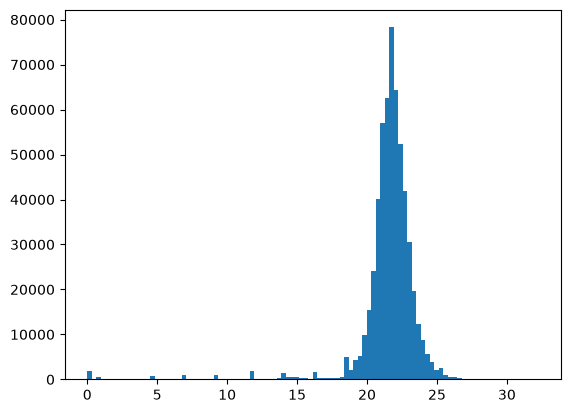

In [6]:
plt.hist(np.log1p(df_price['price_value']), bins=100)
plt.show()

<div dir="rtl" style="text-align:right; font-family:'Segoe UI','B Nazanin',Arial,sans-serif; font-size:15px; line-height:2;">
نمودار توزیع لگاریتم قیمت (log1p) را نشان می‌دهد. توزیع کاملاً نرمال نیست: بدنه‌ی اصلی داده (تقریباً بین ۱۸ تا ۲۶) شکلی نسبتاً زنگوله‌ای دارد، اما یک دسته‌ی کوچک و جدا در سمت چپ (بین ۰ تا ۱۵) نیز دیده می‌شود که باعث می‌شود توزیع به‌صورت <b>دو‌مودی (bimodal)</b> و <b>چوله به چپ</b> باشد. همین انحراف از نرمال بودن است که استفاده از آزمون ناپارامتریک Mann-Whitney را به‌جای t-test برای مقایسه‌ی گروه‌ها توجیه می‌کند.
</div>

<div dir="rtl" style="text-align:right; font-family:'Segoe UI','B Nazanin',Arial,sans-serif; font-size:15px; line-height:2;">
<b>امکانات لاکچری:</b><br>
فرض صفر (H0): توزیع قیمت آگهی‌های دارای امکانات لاکچری و بدون آن یکسان است (تفاوتی وجود ندارد).<br>
فرض مقابل (H1): توزیع قیمت آگهی‌های دارای امکانات لاکچری و بدون آن با هم متفاوت است.
</div>

In [7]:
group_luxury_true = df_price[df_price['has_luxury']]['price_value']
group_luxury_false = df_price[~df_price['has_luxury']]['price_value']

u_stat, p_value = stats.mannwhitneyu(group_luxury_true, group_luxury_false, alternative='two-sided')

print(f"U: {u_stat}, p-value: {p_value}")

U: 1838835768.5, p-value: 4.296161216158544e-08


<div dir="rtl" style="text-align:right; font-family:'Segoe UI','B Nazanin',Arial,sans-serif; font-size:15px; line-height:2;">
تفاوت قیمت بین آگهی‌های دارای امکانات <b>لاکچری</b> و بدون آن از نظر آماری معنادار است (U=1838835768.5, p≈4.3×10⁻⁸).
</div>

<div dir="rtl" style="text-align:right; font-family:'Segoe UI','B Nazanin',Arial,sans-serif; font-size:15px; line-height:2;">
<b>امکانات غیرلاکچری:</b><br>
فرض صفر (H0): توزیع قیمت آگهی‌های دارای امکانات غیرلاکچری و بدون آن یکسان است (تفاوتی وجود ندارد).<br>
فرض مقابل (H1): توزیع قیمت آگهی‌های دارای امکانات غیرلاکچری و بدون آن با هم متفاوت است.
</div>

In [8]:
group_nl_true = df_price[df_price['has_non_luxury']]['price_value']
group_nl_false = df_price[~df_price['has_non_luxury']]['price_value']

u_stat_nl, p_value_nl = stats.mannwhitneyu(group_nl_true, group_nl_false, alternative='two-sided')

print(f"U: {u_stat_nl}, p-value: {p_value_nl}")

U: 39535841395.5, p-value: 0.0


<div dir="rtl" style="text-align:right; font-family:'Segoe UI','B Nazanin',Arial,sans-serif; font-size:15px; line-height:2;">
تفاوت قیمت بین آگهی‌های دارای امکانات <b>غیرلاکچری</b> و بدون آن نیز از نظر آماری کاملاً معنادار است (U=39535841395.5, p<0.001)، و با توجه به بزرگ‌تر بودن آماره‌ی U و p-value نزدیک به صفر نسبت به حالت لاکچری، شواهد قوی‌تری برای تفاوت بین دو گروه غیرلاکچری وجود دارد.
</div>